# **Multi-class classification matrix**

In 27_0 we learned how to deal with binary classification problems. Like where the output value is either 0 or 1. Now we will learn how to deal with multi-class classification problems. Like where the output value can be more than 2 values.



In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('IRIS.csv')
print(df['species'].nunique())
print(df['species'].unique())
df.head()

3
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('species', axis=1), df['species'], test_size=0.2, random_state=2)

# now we will be comparing the predictions of logistic reg and decision tree classifier
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train, y_train)
y_pred1 = clf1.predict(X_test)

clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)

In [5]:
def prt(y_test, y_pred, model_name):
    print(f"{model_name}")
    print(accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print()


prt(y_test, y_pred1, 'LOGISTIC REGRESSION')
prt(y_test, y_pred2, 'DECISION TREE')

# as we can see both the models are giving the same accuracy

LOGISTIC REGRESSION
0.9666666666666667
[[14  0  0]
 [ 0  7  1]
 [ 0  0  8]]

DECISION TREE
0.9333333333333333
[[14  0  0]
 [ 0  7  1]
 [ 0  1  7]]



In [6]:
pd.DataFrame(confusion_matrix(y_test, y_pred1), columns=list(range(0,3)))   # this is how we print confusion matrix in a data frame format

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [11]:
def prt2(y_test, y_pred, model_name):
    print(f"{model_name}")
    print("Precision: ", precision_score(y_test, y_pred, average='weighted'))
    print("Recall: ", recall_score(y_test, y_pred, average='weighted'))
    print()


prt2(y_test, y_pred1, 'LOGISTIC REGRESSION')
prt2(y_test, y_pred2, 'DECISION TREE')

LOGISTIC REGRESSION
Precision:  0.9703703703703703
Recall:  0.9666666666666667

DECISION TREE
Precision:  0.9333333333333333
Recall:  0.9333333333333333



Use Macro when you want to ensure the model is performing well across all categories, not just the ones with the most dat

- **average ='macro'**: It gives the mean of precision of all the categories in output. Use this when you have a balanced ouput categories.

- **average='micro'**: Calculates metrics globally by counting the total true positives, false negatives and false positives. It is dominated by the majority class. Use this when you dont have a balanced output categories.

- **average='weighted'**: Calculates the score for each class but weights them by the number of samples in that class (Support). This is usually the default for "overall" performance if you don't care about minority classes as much.
Summary: Use Macro when you want to ensure the model is performing well across all categories, not just the ones with the most data.


**TO UNDERSTAND BETTER CLICK ON THIS LINK :** https://youtu.be/iK-kdhJ-7yI?si=7FNTyj6R1-k-UvJP&t=1938

### **Finding Recall and Precision of individual categories**


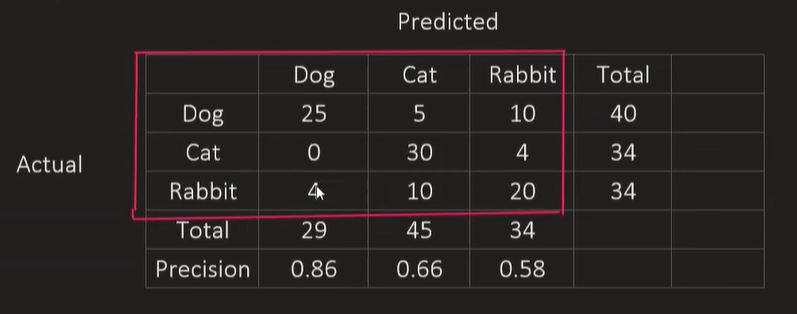


- Recall of Dog : 25 / 40 = 0.62
- Recall of Cat : 25 / 34 = 0.88
- Recall of Rabbit : 25 / 34 = 0.58

You can also go for **macro**, **micro**, or **weighted** recall.


- Precision of Dog : 25 / 29 = 0.86
- Precision of Cat : 30 / 45 = 0.66
- Precision of Rabbit : 20 / 34 = 0.58

You can also go for **macro**, **micro**, or **weighted** precision.